In [1]:
import chephy_model as cpm
from pathlib import Path
import time
import numpy as np
from sklearn.model_selection import train_test_split
import run
import pandas as pd


/home/dsi/chenbis/anaconda3/envs/chephy2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def run_by_score(score):

    start_time = time.time()

    
    methods=["spectral", "louvain", "dbscan", "kmeans", "label_propagation"]

    if score == 3:
        param_grid = {
            'spectral': {'n_clusters': [250, 200, 199, 190, 180, 170, 160, 150, 140, 130, 120, 110, 100]},
            'kmeans': {'n_clusters': [250, 200, 199, 190, 180, 170, 160, 150, 140, 130, 120, 110, 100]},
            "louvain":{},
            "dbscan":{"eps":[0.9], "min_samples":[2]},
            "label_propagation": {"seed": [0, 1, 2]}
        }

    if score == 32:
        param_grid = {
            'spectral': {'n_clusters': [500, 450, 411, 400, 350, 300, 250, 200]},
            'kmeans': {'n_clusters': [500, 450, 411, 400, 350, 300, 250, 200]},
            "louvain":{},
            "dbscan":{"eps":[0.9], "min_samples":[2]},
            "label_propagation": {"seed": [0, 1, 2]}
        }

    if score == 321:
        param_grid = {
            'spectral': {'n_clusters': [550, 500, 494, 450, 400, 350, 300, 250, 200]},
            'kmeans': {'n_clusters': [550, 500, 494, 450, 400, 350, 300, 250, 200]},
            "louvain":{},
            "dbscan":{"eps":[0.9], "min_samples":[2]},
            "label_propagation": {"seed": [0, 1, 2]}
        }

    if score == 3210:
        param_grid = {
            'spectral': {'n_clusters': [1250, 1200, 1196, 1050, 1000, 950, 900, 800, 700, 600, 500]},
            'kmeans': {'n_clusters': [1200, 1196, 1050, 1000, 950, 900, 800, 700, 600, 500]},
            "louvain":{},
            "dbscan":{"eps":[0.9], "min_samples":[2]},
            "label_propagation": {"seed": [0, 1, 2]}
        }

    # max_mutations = args.mutations
    # out_folder = f"output/{run.get_time()}"
    out_folder = f"output_by_scores/{score}"
    out_name = "neighbors"
    params_file = "stats.csv"
    right = 4
    left = 4
    input_file = f"../files/vdjdb_score{score}.csv"
    max_dist=1
    label_header = "antigen.epitope"
    cdr3_header = "cdr3"

    args = {
        "out_folder": out_folder,
        "out_name": out_name,
        "params_file": params_file,
        "right": right,
        "left": left,
        "input_file": input_file,
        "max_dist": max_dist,
        "label_header": label_header,
        "cdr3_header": cdr3_header
    }

    path = Path(f"{out_folder}")
    path.mkdir(parents=True, exist_ok=True)

    data = run.load_dataframe(input_file)

    # data = read_csv_files_from_folder()

    data = run.prepare_data(data, cdr3_header, label_header)    
    data = cpm.truncate_sequences(data, cdr3_header, right, left)

    sequences = set(data["cdr3_truncated"])
    chephy_matrix, hamming_matrix, sequences_list = cpm.find_che_phy_dist(sequences)
    data['index'] = data['cdr3_truncated'].apply(lambda x: sequences_list.index(x) if x in sequences_list else -1)
    sequence_indices = np.arange(len(sequences_list))



    # Split into train and test (80% train, 20% test)
    train_indices, test_indices = train_test_split(sequence_indices, test_size=0.2)

    # Extract submatrix for training set
    train_distance_matrix = chephy_matrix[np.ix_(train_indices, train_indices)]
    hamming_training_matrix = hamming_matrix[np.ix_(train_indices, train_indices)]


    clusters = run.train(train_distance_matrix, train_indices, data, out_folder, hamming_training_matrix, enrich=True, threshold=max_dist, methods=methods, param_grid=param_grid)

    test_predictions, accuracy, recall, f1 = run.test(data, test_indices, chephy_matrix, train_indices, clusters)
    data.to_csv(f"{out_folder}/data.csv")
    execution_time = time.time() - start_time
    run.save_stats(f"{out_folder}/{params_file}", args, execution_time)

    metrics_df = pd.DataFrame([{
        'test_accuracy': accuracy,
        'test_recall': recall,
        'test_f1_score': f1
    }
    ])
    metrics_df.to_csv(f'{out_folder}/test_metrics.csv', index=False)


In [3]:
run_by_score(3)
run_by_score(32)
run_by_score(321)

Generating walks (CPU: 1):   0%|          | 0/2 [00:00<?, ?it/s]

Generating walks (CPU: 4):   0%|          | 0/2 [00:00<?, ?it/s]


Generating walks (CPU: 3):   0%|          | 0/2 [00:00<?, ?it/s]



Generating walks (CPU: 7):   0%|          | 0/2 [00:00<?, ?it/s]

Computing transition probabilities: 100%|██████████| 652/652 [00:00<00:00, 34782.27it/s]


Computing transition probabilities: 100%|██████████| 652/652 [00:00<00:00, 33598.96it/s]


Generating walks (CPU: 1):   0%|          | 0/2 [00:00<?, ?it/s]




Generating walks (CPU: 2):   0%|          | 0/2 [00:00<?, ?it/s]

Generating walks (CPU: 3):   0%|          | 0/2 [00:00<?, ?it/s]

Generating walks (CPU: 2):   0%|          | 0/2 [00:00<?, ?it/s]

Generating walks (CPU: 4):   0%|          | 0/2 [00:00<?, ?it/s]


Generating walks (CPU: 6):   0%|          | 0/2 [00:00<?, ?it/s]

Generating walks (CPU: 7):   0%|          | 0/2 [00:00<?, ?it/s]



Generating walks (CPU: 2):   0%|          | 0/2 [00:00<?, ?it/s]





Generating wa

Test Accuracy: 0.38688524590163936, Recall: 0.38688524590163936, F1-score: 0.26942803491225825


Generating walks (CPU: 1):   0%|          | 0/2 [00:00<?, ?it/s]

Computing transition probabilities: 100%|██████████| 1624/1624 [00:00<00:00, 17692.66it/s]


Computing transition probabilities: 100%|██████████| 1624/1624 [00:00<00:00, 17176.77it/s]

Generating walks (CPU: 1):   0%|          | 0/2 [00:00<?, ?it/s]0:00<00:00, 5488.06it/s]





Computing transition probabilities: 100%|██████████| 1624/1624 [00:00<00:00, 17604.82it/s]


Generating walks (CPU: 3):   0%|          | 0/2 [00:00<?, ?it/s]0:00<00:00, 6378.58it/s]


Generating walks (CPU: 2):   0%|          | 0/2 [00:00<?, ?it/s]


Computing transition probabilities: 100%|██████████| 1624/1624 [00:00<00:00, 10036.93it/s]


Generating walks (CPU: 1):   0%|          | 0/2 [00:00<?, ?it/s]



Generating walks (CPU: 3):   0%|          | 0/2 [00:00<?, ?it/s]



Generating walks (CPU: 5):   0%|          | 0/2 [00:00<?, ?it/s]

Generating walks (CPU: 3):   0%|          | 0/2 [00:00<?, ?it/s]


Generating walks (CPU: 4):   0%|          

Test Accuracy: 0.17647058823529413, Recall: 0.17647058823529413, F1-score: 0.07873358289896457


Generating walks (CPU: 2):   0%|          | 0/2 [00:00<?, ?it/s]

Generating walks (CPU: 3):   0%|          | 0/2 [00:00<?, ?it/s]


Generating walks (CPU: 4):   0%|          | 0/2 [00:00<?, ?it/s]



Generating walks (CPU: 5):   0%|          | 0/2 [00:00<?, ?it/s]




Generating walks (CPU: 6):   0%|          | 0/2 [00:00<?, ?it/s]





Generating walks (CPU: 8):   0%|          | 0/1 [00:00<?, ?it/s]






Generating walks (CPU: 7):   0%|          | 0/2 [00:00<?, ?it/s]

Computing transition probabilities: 100%|██████████| 4563/4563 [00:00<00:00, 30147.52it/s]


Generating walks (CPU: 3):   0%|          | 0/2 [00:00<?, ?it/s]





Computing transition probabilities: 100%|██████████| 4563/4563 [00:00<00:00, 30197.51it/s]







Generating walks (CPU: 8):   0%|          | 0/1 [00:00<?, ?it/s]




Computing transition probabilities: 100%|██████████| 4563/4563 [00:00<00:00, 31032.65it/s]

Generating walks (CPU: 2):   0%|          | 0/2 [00:00<?, ?it/s]


Generating walks (CPU: 5):   0%|  

Test Accuracy: 0.17679558011049723, Recall: 0.17679558011049723, F1-score: 0.07558643136835891


In [4]:
import os
import glob

# Get all subdirectories in output_by_scores
result_folders = glob.glob(f"{out_folder.split('/')[0]}/*")

# Collect all test metrics
all_metrics = []

for folder in result_folders:
    metrics_path = f"{folder}/test_metrics.csv"
    stats_path = f"{folder}/stats.csv"
    
    if os.path.exists(metrics_path):
        metrics = pd.read_csv(metrics_path)
        
        # Try to get score from folder name
        score_name = os.path.basename(folder)
        metrics['score'] = score_name
        
        # Try to load stats if available
        if os.path.exists(stats_path):
            stats = pd.read_csv(stats_path)
            if 'execution_time' in stats.columns:
                metrics['execution_time'] = stats['execution_time'].values[0]
        
        all_metrics.append(metrics)

# Combine all metrics
if all_metrics:
    results_df = pd.concat(all_metrics, ignore_index=True)
    
    # Sort by score
    results_df = results_df.sort_values('score')
    
    print("Summary of all runs:")
    print(results_df)
    print("\n" + "="*60)
    print("\nStatistics across all runs:")
    print(results_df[['test_accuracy', 'test_recall', 'test_f1_score']].describe())
    print("\n" + "="*60)
    print("\nBest performing runs:")
    print("\nBy Accuracy:")
    print(results_df.nlargest(5, 'test_accuracy')[['score', 'test_accuracy', 'test_recall', 'test_f1_score']])
    print("\nBy F1 Score:")
    print(results_df.nlargest(5, 'test_f1_score')[['score', 'test_accuracy', 'test_recall', 'test_f1_score']])
else:
    print("No metrics files found in output_by_scores folder")

NameError: name 'out_folder' is not defined

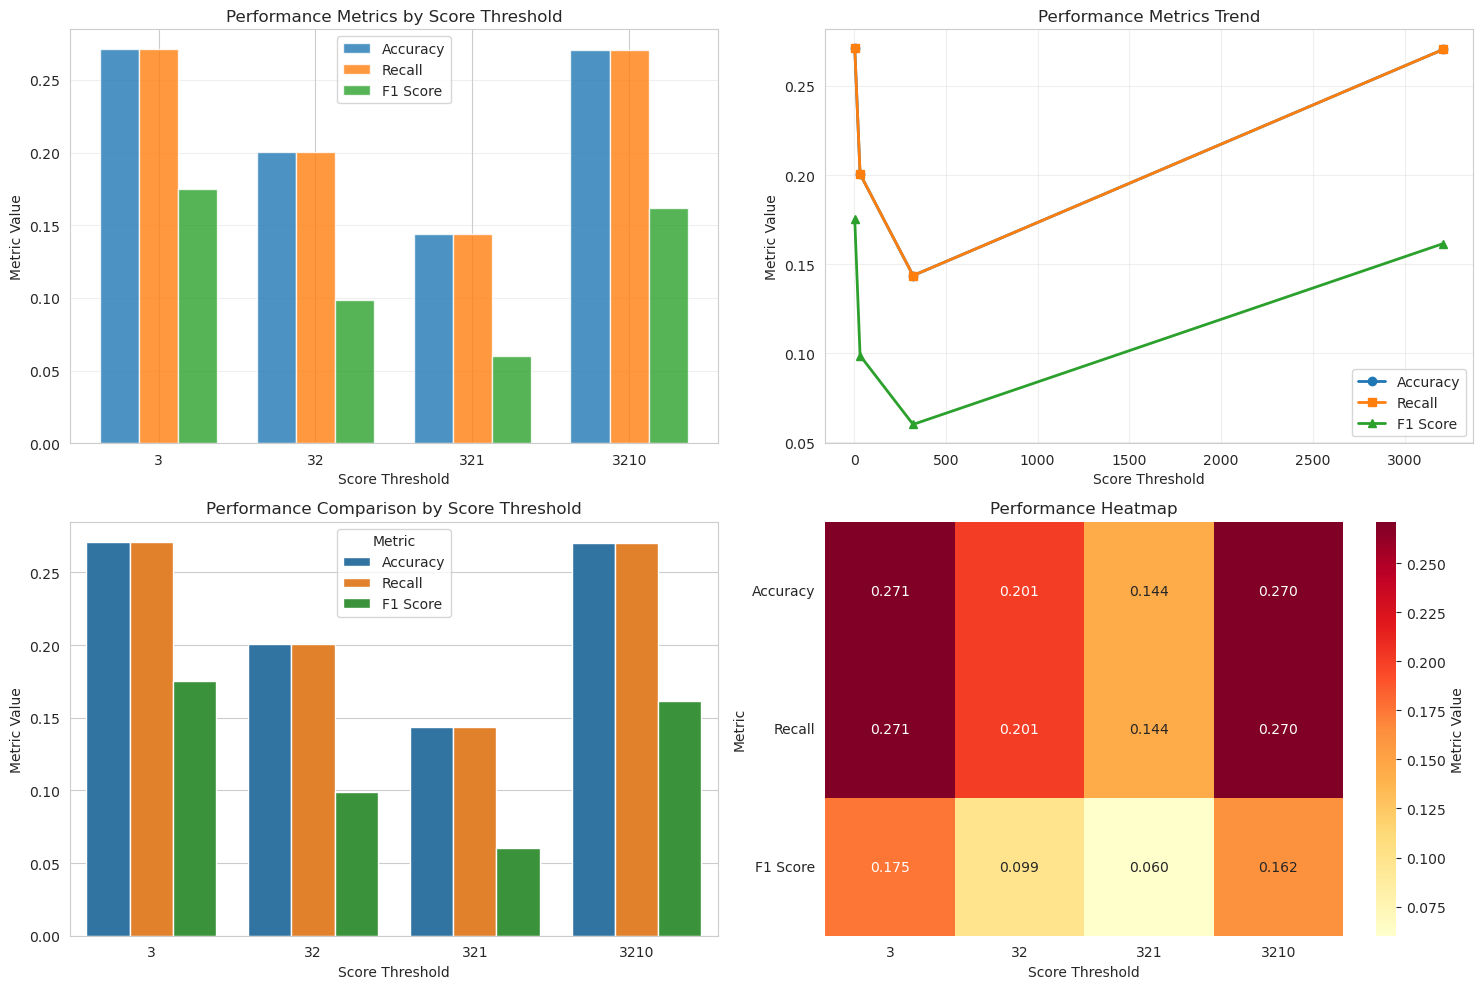

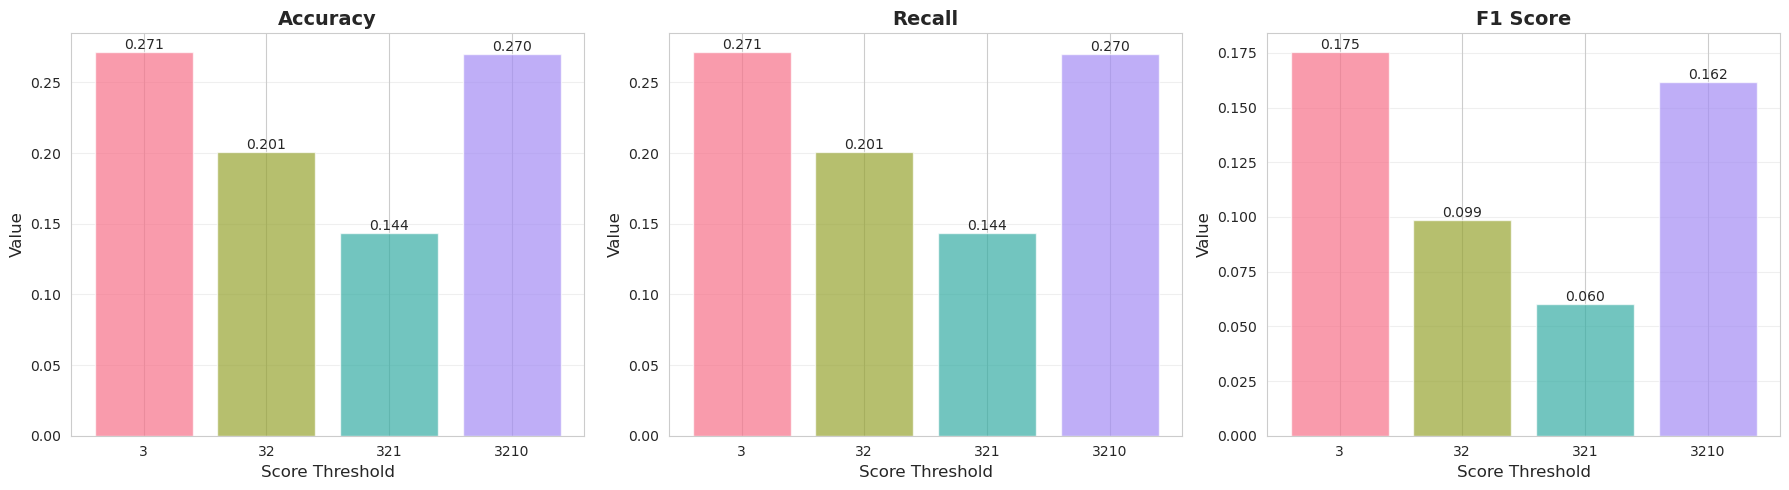


Plots saved to output_by_scores/ folder
- performance_analysis.png: Comprehensive 4-panel analysis
- individual_metrics.png: Individual metric comparisons


In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bar plot comparing all metrics across scores
ax1 = axes[0, 0]
results_df_sorted = results_df.sort_values('score')
x_pos = np.arange(len(results_df_sorted))
width = 0.25

ax1.bar(x_pos - width, results_df_sorted['test_accuracy'], width, label='Accuracy', alpha=0.8)
ax1.bar(x_pos, results_df_sorted['test_recall'], width, label='Recall', alpha=0.8)
ax1.bar(x_pos + width, results_df_sorted['test_f1_score'], width, label='F1 Score', alpha=0.8)

ax1.set_xlabel('Score Threshold')
ax1.set_ylabel('Metric Value')
ax1.set_title('Performance Metrics by Score Threshold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df_sorted['score'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Line plot showing trend of metrics
ax2 = axes[0, 1]
results_df_sorted['score_numeric'] = pd.to_numeric(results_df_sorted['score'])
results_df_sorted = results_df_sorted.sort_values('score_numeric')

ax2.plot(results_df_sorted['score_numeric'], results_df_sorted['test_accuracy'], marker='o', label='Accuracy', linewidth=2)
ax2.plot(results_df_sorted['score_numeric'], results_df_sorted['test_recall'], marker='s', label='Recall', linewidth=2)
ax2.plot(results_df_sorted['score_numeric'], results_df_sorted['test_f1_score'], marker='^', label='F1 Score', linewidth=2)

ax2.set_xlabel('Score Threshold')
ax2.set_ylabel('Metric Value')
ax2.set_title('Performance Metrics Trend')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Grouped bar chart for better comparison
ax3 = axes[1, 0]
results_melted = results_df_sorted.melt(id_vars=['score'], 
                                         value_vars=['test_accuracy', 'test_recall', 'test_f1_score'],
                                         var_name='Metric', value_name='Value')
results_melted['Metric'] = results_melted['Metric'].str.replace('test_', '').str.replace('_', ' ').str.title()

sns.barplot(data=results_melted, x='score', y='Value', hue='Metric', ax=ax3)
ax3.set_xlabel('Score Threshold')
ax3.set_ylabel('Metric Value')
ax3.set_title('Performance Comparison by Score Threshold')
ax3.legend(title='Metric')

# 4. Heatmap of metrics
ax4 = axes[1, 1]
heatmap_data = results_df_sorted[['test_accuracy', 'test_recall', 'test_f1_score']].T
heatmap_data.columns = results_df_sorted['score'].values

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Metric Value'})
ax4.set_xlabel('Score Threshold')
ax4.set_ylabel('Metric')
ax4.set_title('Performance Heatmap')
ax4.set_yticklabels(['Accuracy', 'Recall', 'F1 Score'], rotation=0)

plt.tight_layout()
plt.savefig('output_by_scores/performance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional individual plots
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

# Individual metric plots with annotations
for idx, metric in enumerate(['test_accuracy', 'test_recall', 'test_f1_score']):
    ax = axes2[idx]
    bars = ax.bar(results_df_sorted['score'], results_df_sorted[metric], alpha=0.7, color=sns.color_palette("husl", 4))
    ax.set_xlabel('Score Threshold', fontsize=12)
    ax.set_ylabel('Value', fontsize=12)
    ax.set_title(f'{metric.replace("test_", "").replace("_", " ").title()}', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('output_by_scores/individual_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPlots saved to output_by_scores/ folder")
print("- performance_analysis.png: Comprehensive 4-panel analysis")
print("- individual_metrics.png: Individual metric comparisons")